In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from matplotlib_venn import venn3
from upsetplot import from_indicators, UpSet

code_list= "../data/matrix_codelists_combined-2025-08-07.csv"
HF_pheno_definitions = "../data/Initial HF phenotype definitions.xlsx"

code_list= pd.read_csv(code_list)
HF_pheno_definitions = pd.read_excel(HF_pheno_definitions, sheet_name="Table 1")

In [2]:
pheno_cols = [c for c in code_list.columns if c.startswith("pheno_")]
print(f"Total phenotype columns: {len(pheno_cols)}")
code_list.head()




Total phenotype columns: 23


,Code,Description,pheno_20,pheno_21,pheno_24,pheno_25,pheno_27,pheno_28,pheno_29,pheno_30,...,pheno_11,pheno_12,pheno_01,pheno_02,pheno_13,pheno_16,pheno_33,pheno_37,Person.count.in.SDE,In.Refset
0,10091002,High output heart failure (disorder),1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0.0,No
1,1010444007,Legal abortion complicated by cardiac failure ...,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,No
2,1010447000,Illegal abortion complicated by cardiac failur...,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,No
3,101281000119107,Congestive heart failure due to cardiomyopathy...,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0.0,No
4,10335000,Chronic right-sided heart failure (disorder),1,1,0,1,0,1,1,1,...,1,1,0,0,0,0,0,0,1275.0,No


#### "manually review the similarity of pheno_28, 29 and 30"

In [3]:
def plot_phenotype_venn(*pheno_nums, data=code_list, figsize=(10, 8)):
    """
    Plot a Venn diagram for phenotype code comparisons with similarity summary.
    
    Returns:
    --------
    dict : Summary statistics of the phenotypes
    """
    from matplotlib_venn import venn2, venn3
    from itertools import combinations
    
    # Validate input
    if len(pheno_nums) < 2 or len(pheno_nums) > 3:
        raise ValueError("Please provide 2 or 3 phenotype numbers")
    
    # Get sets for phenotype
    pheno_sets = {}
    for num in pheno_nums:
        col_name = f"pheno_{num}"
        if col_name not in data.columns:
            raise ValueError(f"Column '{col_name}' not found in data")
        pheno_sets[num] = set(data.loc[data[col_name] == 1, "Code"])
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    colors = ["#4C78A8", "#F58518", "#54A24B", "#9D755D", "#72B7B2", "#E45756", "#B279A2"]
    
    # Plot venn diagram
    if len(pheno_nums) == 2:
        num1, num2 = pheno_nums
        v = venn2([pheno_sets[num1], pheno_sets[num2]], 
                  set_labels=(f"pheno_{num1}", f"pheno_{num2}"),
                  ax=ax,
                  set_colors=colors[:2])
    else:  
        num1, num2, num3 = pheno_nums
        v = venn3([pheno_sets[num1], pheno_sets[num2], pheno_sets[num3]], 
                  set_labels=(f"pheno_{num1}", f"pheno_{num2}", f"pheno_{num3}"),
                  ax=ax,
                  set_colors=colors[:3])
    
    for label in v.set_labels:
        if label:
            label.set_fontsize(12)
            label.set_fontweight("bold")
    
    for text in v.subset_labels:
        if text:
            text.set_fontsize(11)
            text.set_fontweight("bold")
    
    ax.set_title(f"Overlap of HF Phenotypes: {', '.join([f'pheno_{n}' for n in pheno_nums])}", 
                 fontsize=14, fontweight="bold", pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Generate summary statistics
    print("\n" + "="*60)
    print("SIMILARITY SUMMARY")
    print("="*60)
    
    # Total codes in each phenotype
    for num in pheno_nums:
        print(f"pheno_{num}: {len(pheno_sets[num])} codes")
    
    # Pairwise intersections (ranked by similarity)
    intersections = []
    for num_a, num_b in combinations(pheno_nums, 2):
        intersection = pheno_sets[num_a] & pheno_sets[num_b]
        size_a = len(pheno_sets[num_a])
        size_b = len(pheno_sets[num_b])
        
        # Jaccard similarity
        union = pheno_sets[num_a] | pheno_sets[num_b]
        jaccard = len(intersection) / len(union) if len(union) > 0 else 0
        
        intersections.append({
            'pair': (num_a, num_b),
            'shared': len(intersection),
            'jaccard': jaccard,
            'size_a': size_a,
            'size_b': size_b
        })
    
    # Sort by Jaccard similarity (descending)
    intersections.sort(key=lambda x: x['jaccard'], reverse=True)
    
    print("\n📊 Ranking by Similarity (Jaccard Index):")
    print("-" * 60)
    for i, item in enumerate(intersections, 1):
        num_a, num_b = item['pair']
        print(f"{i}. pheno_{num_a} ↔ pheno_{num_b}")
        print(f"   Shared codes: {item['shared']} (Jaccard: {item['jaccard']:.2%})")
        print(f"   pheno_{num_a} unique: {item['size_a'] - item['shared']}")
        print(f"   pheno_{num_b} unique: {item['size_b'] - item['shared']}")
        print()
    
    if len(pheno_nums) == 3:
        all_three = pheno_sets[num1] & pheno_sets[num2] & pheno_sets[num3]
        print(f"🎯 All three phenotypes share: {len(all_three)} codes")
    
    print("="*60 + "\n")
    
    return intersections


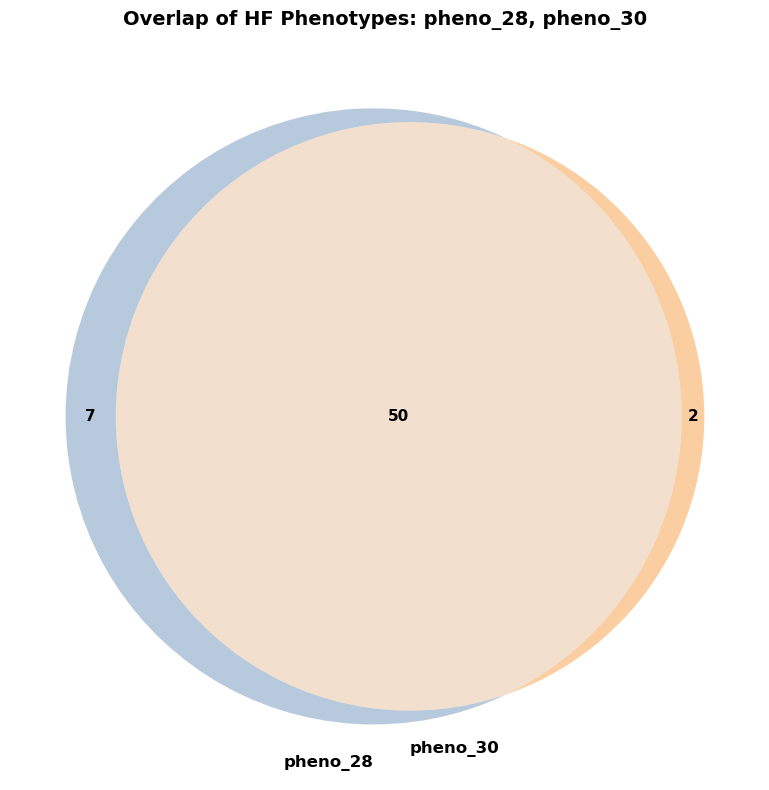


SIMILARITY SUMMARY
pheno_28: 57 codes
pheno_30: 52 codes

📊 Ranking by Similarity (Jaccard Index):
------------------------------------------------------------
1. pheno_28 ↔ pheno_30
   Shared codes: 50 (Jaccard: 84.75%)
   pheno_28 unique: 7
   pheno_30 unique: 2




[{'pair': (28, 30),
  'shared': 50,
  'jaccard': 0.847457627118644,
  'size_a': 57,
  'size_b': 52}]

In [4]:
plot_phenotype_venn(28, 30)

Higher similarity is found between pheno_28 and pheno_30: jaccard index >80%

pheno_30 and 28 appear to be the Heart failure codelist defined in the CCU003_03 and CCU035_01 project (codelist in csv for pheno28 and a). This codelist is used to identify heart failure in EHR data using a broad set of ICD10 and SNOMED codes covering general heart failure diagnoses

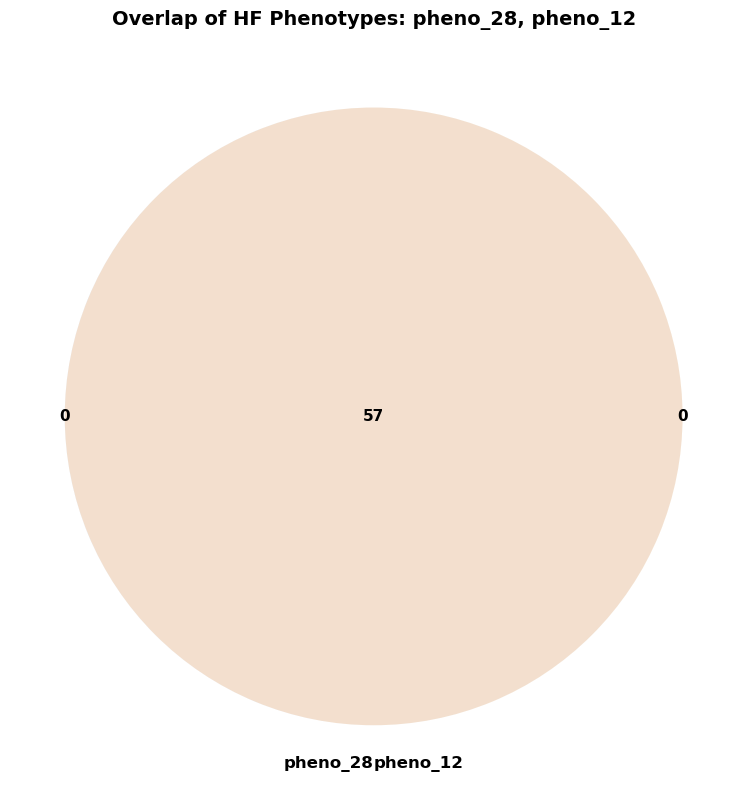


SIMILARITY SUMMARY
pheno_28: 57 codes
pheno_12: 57 codes

📊 Ranking by Similarity (Jaccard Index):
------------------------------------------------------------
1. pheno_28 ↔ pheno_12
   Shared codes: 57 (Jaccard: 100.00%)
   pheno_28 unique: 0
   pheno_12 unique: 0




[{'pair': (28, 12), 'shared': 57, 'jaccard': 1.0, 'size_a': 57, 'size_b': 57}]

In [5]:
plot_phenotype_venn(28,12)

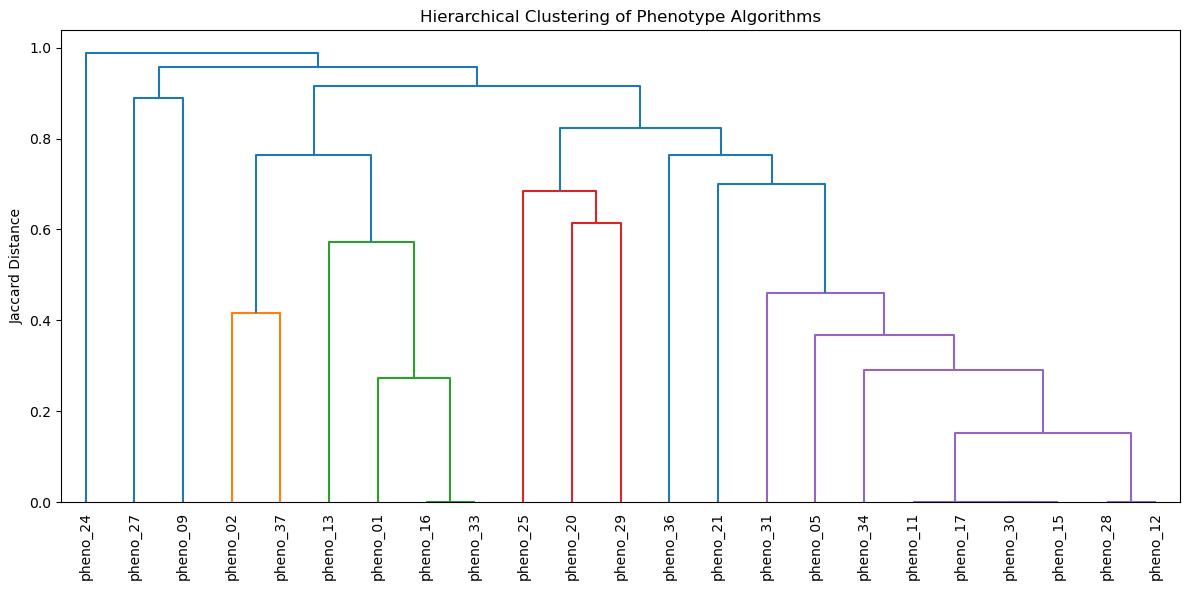

   phenotype  cluster
4   pheno_27        1
14  pheno_09        2
18  pheno_02        3
22  pheno_37        4
20  pheno_16        5
21  pheno_33        5
17  pheno_01        6
19  pheno_13        7
0   pheno_20        8
6   pheno_29        9
3   pheno_25       10
15  pheno_11       11
16  pheno_12       11
11  pheno_15       11
12  pheno_17       11
5   pheno_28       11
7   pheno_30       11
9   pheno_34       12
13  pheno_05       13
8   pheno_31       14
1   pheno_21       15
10  pheno_36       16
2   pheno_24       17


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Select phenotype columns
pheno_cols = [c for c in code_list.columns if c.startswith("pheno_")]

X = code_list[pheno_cols].astype(int).T
dist_vec = pdist(X.values, metric="jaccard")
dist_mat = squareform(dist_vec)

#Hierarchical clustering
Z = linkage(dist_vec, method="average")  

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=X.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering of Phenotype Algorithms")
plt.ylabel("Jaccard Distance")
plt.tight_layout()
plt.show()

# Assign clusters using a distance threshold
cluster_labels = fcluster(Z, t=0.2, criterion="distance")

cluster_df = pd.DataFrame({
    "phenotype": X.index,
    "cluster": cluster_labels
}).sort_values(["cluster", "phenotype"])

print(cluster_df)